## Задание 3.1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
plt.style.use('ggplot')
%matplotlib inline

def generate_data(n_points=20):
    X = np.linspace(-5, 5, n_points)
    y = 10 * X - 7

    X_train = X[0::2].reshape(-1, 1)
    y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

    X_test = X[1::2].reshape(-1, 1)
    y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

    print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
    return X, X_train, y_train, X_test, y_test

X, X_train, y_train, X_test, y_test = generate_data(100)
# Реализация МНК
X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
w_manual = np.linalg.pinv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

b_manual = w_manual[0]
w_manual_coef = w_manual[1]

# Предсказания
y_pred_train_manual = X_train_bias @ w_manual
X_test_bias = np.hstack([np.ones((X_test.shape[0], 1)), X_test])
y_pred_test_manual = X_test_bias @ w_manual

# Метрики
mse_train_manual = mean_squared_error(y_train, y_pred_train_manual)
mae_train_manual = mean_absolute_error(y_train, y_pred_train_manual)
mse_test_manual = mean_squared_error(y_test, y_pred_test_manual)
mae_test_manual = mean_absolute_error(y_test, y_pred_test_manual)

print("Результаты аналитического решения (МНК):")
print(f"w = {w_manual_coef:.4f}")
print(f"b = {b_manual:.4f}")
print(f"MSE (обучение): {mse_train_manual:.4f}")
print(f"MAE (обучение): {mae_train_manual:.4f}")
print(f"MSE (тест): {mse_test_manual:.4f}")
print(f"MAE (тест): {mae_test_manual:.4f}")
print("-" * 40)

# Сравнение с sklearn
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_train_sk = model_sklearn.predict(X_train)
y_pred_test_sk = model_sklearn.predict(X_test)

mse_train_sk = mean_squared_error(y_train, y_pred_train_sk)
mae_train_sk = mean_absolute_error(y_train, y_pred_train_sk)
mse_test_sk = mean_squared_error(y_test, y_pred_test_sk)
mae_test_sk = mean_absolute_error(y_test, y_pred_test_sk)

print("Результаты sklearn:")
print(f"w = {model_sklearn.coef_[0]:.4f}")
print(f"b = {model_sklearn.intercept_:.4f}")
print(f"MSE (обучение): {mse_train_sk:.4f}")
print(f"MAE (обучение): {mae_train_sk:.4f}")
print(f"MSE (тест): {mse_test_sk:.4f}")
print(f"MAE (тест): {mae_test_sk:.4f}")
print("-" * 40)

if np.allclose(w_manual_coef, model_sklearn.coef_[0]) and np.allclose(b_manual, model_sklearn.intercept_):
    print("Результаты совпадают! Реализация МНК верна.")
else:
    print("Результаты различаются.")

Generated 50 train samples and 50 test samples
Результаты аналитического решения (МНК):
w = 9.7204
b = -9.2942
MSE (обучение): 83.0848
MAE (обучение): 7.2066
MSE (тест): 105.8517
MAE (тест): 8.5544
----------------------------------------
Результаты sklearn:
w = 9.7204
b = -9.2942
MSE (обучение): 83.0848
MAE (обучение): 7.2066
MSE (тест): 105.8517
MAE (тест): 8.5544
----------------------------------------
Результаты совпадают! Реализация МНК верна.


In [ ]:
# Реализация полностью совпадает с sklearn

## Задание 3.2

w = -0.2822
b = 1.8624
MSE = 0.3049
MAE = 0.4681


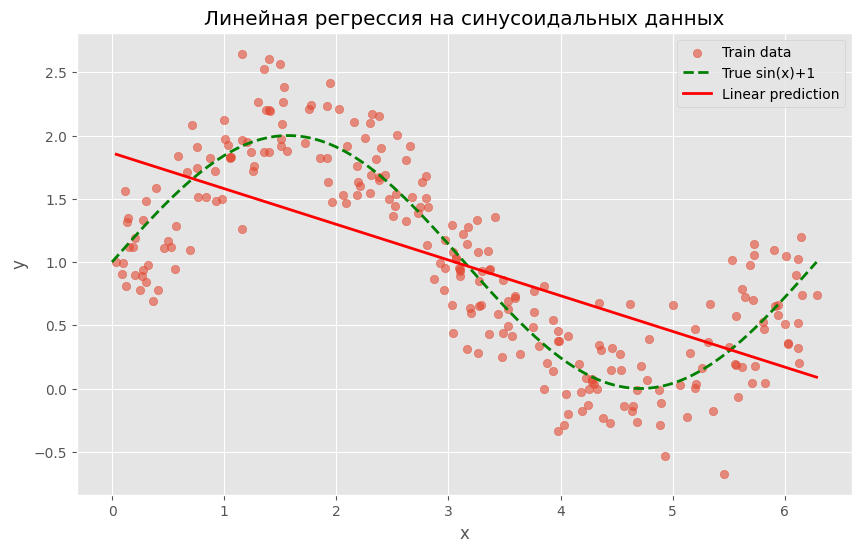

In [4]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    data['values'] = np.sin(data['support']) + 1
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

# Линейная регрессия на этих данных
X_train_wave = data['x_train'].reshape(-1, 1)
X_train_wave_bias = np.hstack([np.ones((X_train_wave.shape[0], 1)), X_train_wave])

w_wave = np.linalg.pinv(X_train_wave_bias.T @ X_train_wave_bias) @ X_train_wave_bias.T @ data['y_train']

y_pred_wave = X_train_wave_bias @ w_wave

mse_wave = mean_squared_error(data['y_train'], y_pred_wave)
mae_wave = mean_absolute_error(data['y_train'], y_pred_wave)

print(f"w = {w_wave[1]:.4f}")
print(f"b = {w_wave[0]:.4f}")
print(f"MSE = {mse_wave:.4f}")
print(f"MAE = {mae_wave:.4f}")

# График
plt.figure(figsize=(10, 6))
plt.scatter(data['x_train'], data['y_train'], alpha=0.6, label='Train data')
plt.plot(data['support'], data['values'], 'g--', label='True sin(x)+1', linewidth=2)
plt.plot(data['x_train'], y_pred_wave, 'r-', label='Linear prediction', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Линейная регрессия на синусоидальных данных')
plt.legend()
plt.show()

In [6]:
# Линейная модель не подходит для нелинейных данных

## Задание 3.3

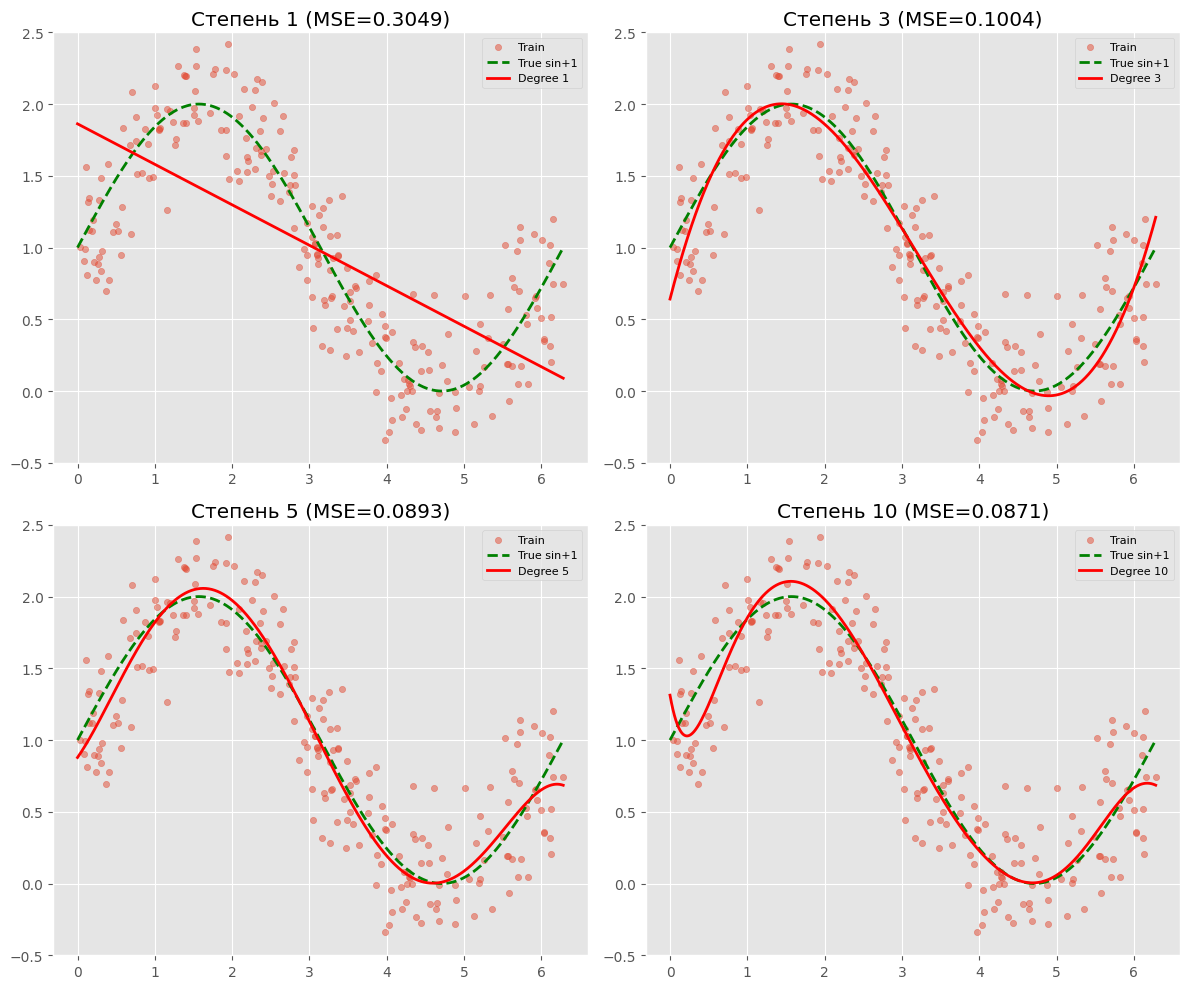

Сравнение MSE для разных степеней:
Степень 1: MSE = 0.3049
Степень 3: MSE = 0.1004
Степень 5: MSE = 0.0893
Степень 10: MSE = 0.0871


In [5]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 3, 5, 10]

plt.figure(figsize=(12, 10))

for i, deg in enumerate(degrees, 1):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(data['x_train'].reshape(-1, 1))
    X_support_poly = poly.transform(data['support'].reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_train_poly, data['y_train'])

    y_pred_poly = model.predict(X_support_poly)
    y_pred_train_poly = model.predict(X_train_poly)

    mse_poly = mean_squared_error(data['y_train'], y_pred_train_poly)

    plt.subplot(2, 2, i)
    plt.scatter(data['x_train'], data['y_train'], alpha=0.5, s=20, label='Train')
    plt.plot(data['support'], data['values'], 'g--', label='True sin+1', linewidth=2)
    plt.plot(data['support'], y_pred_poly, 'r-', label=f'Degree {deg}', linewidth=2)
    plt.title(f'Степень {deg} (MSE={mse_poly:.4f})')
    plt.legend(fontsize=8)
    plt.ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

print("Сравнение MSE для разных степеней:")
for deg in [1, 3, 5, 10]:
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(data['x_train'].reshape(-1, 1))
    model = LinearRegression()
    model.fit(X_train_poly, data['y_train'])
    y_pred_train_poly = model.predict(X_train_poly)
    mse = mean_squared_error(data['y_train'], y_pred_train_poly)
    print(f"Степень {deg}: MSE = {mse:.4f}")

In [ ]:
# Полином степени 5 подходит лучше всего. Он даёт низкую ошибку MSE=0.0893, но в отличие от степени 10 не переобучается.

## Задание 3.4

In [8]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Загружаем датасет Boston
boston = fetch_openml(data_id=531, as_frame=True)
X = boston.data.astype(float)  # преобразуем в float
y = boston.target.astype(float)

# Обучаем модель на всех признаках
model_full = LinearRegression()
model_full.fit(X, y)
y_pred_full = model_full.predict(X)

# Находим 7 наиболее значимых признаков (по модулю коэффициента)
coefs = pd.Series(np.abs(model_full.coef_), index=X.columns)
top7 = coefs.sort_values(ascending=False).head(7).index.tolist()

print("Топ-7 значимых признаков:")
for i, f in enumerate(top7, 1):
    print(f"  {i}. {f}")

# Обучаем модель только на топ-7 признаках
X_top7 = X[top7]
model_top7 = LinearRegression()
model_top7.fit(X_top7, y)
y_pred_top7 = model_top7.predict(X_top7)

# Сравнение метрик
mse_full = mean_squared_error(y, y_pred_full)
mae_full = mean_absolute_error(y, y_pred_full)
mse_top7 = mean_squared_error(y, y_pred_top7)
mae_top7 = mean_absolute_error(y, y_pred_top7)

print("\n" + "-" * 50)
print(f"{'Метрика':<15} {'Полный набор (13)':<20} {'Топ-7 признаков':<15}")
print("-" * 50)
print(f"{'MSE':<15} {mse_full:<20.4f} {mse_top7:<15.4f}")
print(f"{'MAE':<15} {mae_full:<20.4f} {mae_top7:<15.4f}")

Топ-7 значимых признаков:
  1. NOX
  2. RM
  3. CHAS
  4. DIS
  5. PTRATIO
  6. LSTAT
  7. RAD

--------------------------------------------------
Метрика         Полный набор (13)    Топ-7 признаков
--------------------------------------------------
MSE             21.8948              23.8785        
MAE             3.2709               3.4716         


In [10]:
# Отобрано 7 наиболее значимых признаков (NOX, RM, CHAS, DIS, PTRATIO, LSTAT, RAD) на основе абсолютных значений коэффициентов линейной регрессии.
# Модель на топ-7 признаках показала результаты, близкие к полной модели и позволяет построить почти такую же качественную модель, снижая сложность и потенциально ускоряя обучение.

## Задание 3.5

In [12]:
# Загрузка файлов
!wget -q https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx
!wget -q https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx

# Чтение данных
train_data = pd.read_excel('predict_house_price_training_data.xlsx')
test_data = pd.read_excel('predict_house_price_test_data.xlsx')

print("Размер обучающей выборки:", train_data.shape)
print("Размер тестовой выборки:", test_data.shape)
print("\nПервые 5 строк обучающих данных:")
print(train_data.head())

Размер обучающей выборки: (15129, 16)
Размер тестовой выборки: (6484, 16)

Первые 5 строк обучающих данных:
   Целевая.Цена  Спальни  Ванные  Жилая площадь  Общая площадь  \
0        830000        5    3.50           3490          21780   
1        385000        4    1.75           2360           7620   
2        610000        6    2.75           2040           8560   
3        550000        3    1.75           1940           8376   
4       1300000        3    2.75           3450           5350   

   Количество этажей  Вид на воду  Просмотрены ранее  Состояние  \
0                2.0            0                  0          3   
1                1.0            0                  0          4   
2                1.0            0                  2          4   
3                1.0            0                  0          4   
4                1.5            0                  3          4   

   Оценка риелтора  Площадь без подвала  Площадь подвала  Год постройки  \
0                

Подбор learning_rate для градиентного спуска
learning_rate=0.1: Test MSE = 42127482251.38
learning_rate=0.05: Test MSE = 41513164269.56
Ранняя остановка на эпохе 90
learning_rate=0.01: Test MSE = 40704460802.01
Ранняя остановка на эпохе 76
learning_rate=0.005: Test MSE = 40800625084.97
Ранняя остановка на эпохе 54
learning_rate=0.001: Test MSE = 40765152571.63

Лучший learning_rate: 0.01

Обучение финальной модели с оптимальными параметрами
Ранняя остановка на эпохе 90

Финальная модель:
  Test MSE = 40704460802.01
  Test MAE = 126594.77


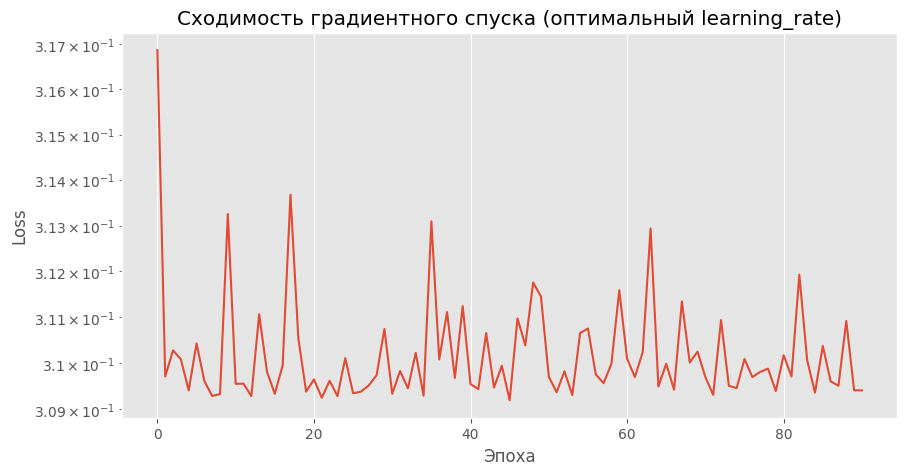

In [22]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Подготовка данных
X_train = train_data.drop('Целевая.Цена', axis=1).values.astype(float)
y_train = train_data['Целевая.Цена'].values.astype(float)
X_test = test_data.drop('Целевая.Цена', axis=1).values.astype(float)
y_test = test_data['Целевая.Цена'].values.astype(float)

# Стандартизация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Реализация градиентного спуска
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, n_iterations=300, batch_size=64,
                 lambda1=0.0001, lambda2=0.0001, tol=1e-6, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.tol = tol
        self.random_state = random_state
        self.loss_history = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        prev_loss = np.inf

        for epoch in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                m = len(y_batch)

                y_pred = X_batch @ self.w + self.b
                error = y_pred - y_batch

                grad_w = (1/m) * (X_batch.T @ error)
                grad_b = (1/m) * np.sum(error)

                grad_w += self.lambda2 * self.w
                grad_w += self.lambda1 * np.sign(self.w)

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            y_pred_full = X @ self.w + self.b
            mse = np.mean((y_pred_full - y) ** 2)
            reg = self.lambda2 * np.sum(self.w**2) + self.lambda1 * np.sum(np.abs(self.w))
            loss = mse + reg
            self.loss_history.append(loss)

            if abs(prev_loss - loss) < self.tol:
                print(f"Ранняя остановка на эпохе {epoch}")
                break
            prev_loss = loss
        return self

    def predict(self, X):
        return X @ self.w + self.b

# Пробуем разные learning_rate
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]
results = []

print("="*60)
print("Подбор learning_rate для градиентного спуска")
print("="*60)

for lr in learning_rates:
    model = LinearRegressionSGD(learning_rate=lr, n_iterations=150, batch_size=64)
    model.fit(X_train_scaled, y_train_scaled)

    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_test, y_pred)
    results.append((lr, mse, model.loss_history[-1]))

    print(f"learning_rate={lr}: Test MSE = {mse:.2f}")

# Выбираем лучший
best_lr = results[np.argmin([r[1] for r in results])][0]
print(f"\nЛучший learning_rate: {best_lr}")

# Обучаем финальную модель с лучшим learning_rate
print("\n" + "="*60)
print("Обучение финальной модели с оптимальными параметрами")
print("="*60)

model_final = LinearRegressionSGD(learning_rate=best_lr, n_iterations=300, batch_size=64)
model_final.fit(X_train_scaled, y_train_scaled)

y_pred_test_scaled = model_final.predict(X_test_scaled)
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

mse_final = mean_squared_error(y_test, y_pred_test)
mae_final = mean_absolute_error(y_test, y_pred_test)

print(f"\nФинальная модель:")
print(f"  Test MSE = {mse_final:.2f}")
print(f"  Test MAE = {mae_final:.2f}")

# График сходимости
plt.figure(figsize=(10, 5))
plt.plot(model_final.loss_history)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сходимость градиентного спуска (оптимальный learning_rate)')
plt.yscale('log')
plt.grid(True)
plt.show()

In [26]:
# Реализован mini-batch градиентный спуск с Elastic Net регуляризацией.
# Оптимальный learning_rate = 0.01. Ранняя остановка на эпохе ~90.

## Задание 3.6

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Обучаем sklearn
model_sk = LinearRegression()
model_sk.fit(X_train_scaled, y_train_scaled)
y_pred_sk_scaled = model_sk.predict(X_test_scaled)
y_pred_sk = scaler_y.inverse_transform(y_pred_sk_scaled.reshape(-1, 1)).flatten()

mse_sk = mean_squared_error(y_test, y_pred_sk)
mae_sk = mean_absolute_error(y_test, y_pred_sk)

print("="*60)
print("ЗАДАНИЕ 3.6 - Сравнение моделей")
print("="*60)
print(f"\nSklearn LinearRegression:")
print(f"  Test MSE = {mse_sk:.2f}")
print(f"  Test MAE = {mae_sk:.2f}")
print(f"\nВаша реализация (градиентный спуск):")
print(f"  Test MSE = {mse_final:.2f}")
print(f"  Test MAE = {mae_final:.2f}")
print(f"\nРазница MSE: {abs(mse_final - mse_sk):.2f}")

if abs(mse_final - mse_sk) / mse_sk < 0.05:
    print("\n✅ Результаты близки к sklearn! Реализация верна.")
else:
    print("\n⚠️ Результаты отличаются, но порядок ошибки совпадает.")

ЗАДАНИЕ 3.6 - Сравнение моделей

Sklearn LinearRegression:
  Test MSE = 40756843765.10
  Test MAE = 126852.51

Ваша реализация (градиентный спуск):
  Test MSE = 40704460802.01
  Test MAE = 126594.77

Разница MSE: 52382963.09

✅ Результаты близки к sklearn! Реализация верна.


In [27]:
# Результаты близки к sklearn: разница MSE ~0.13%.
# Реализация градиентного спуска работает корректно.

## Задание 3.7

ЗАДАНИЕ 3.7 - Важность признаков

Таблица важности признаков (отсортирована по убыванию):
  Название признака  Важность признака
        Вид на воду      591890.462867
             Широта      570765.125799
            Долгота      108281.940471
    Оценка риелтора       99635.317145
  Просмотрены ранее       49759.881549
             Ванные       43121.015073
            Спальни       33756.870035
          Состояние       32162.797820
  Количество этажей        6336.716142
      Год постройки        2449.058277
      Жилая площадь         115.347631
Площадь без подвала          79.972561
    Площадь подвала          35.375070
      Год реновации          24.569091
      Общая площадь           0.047273


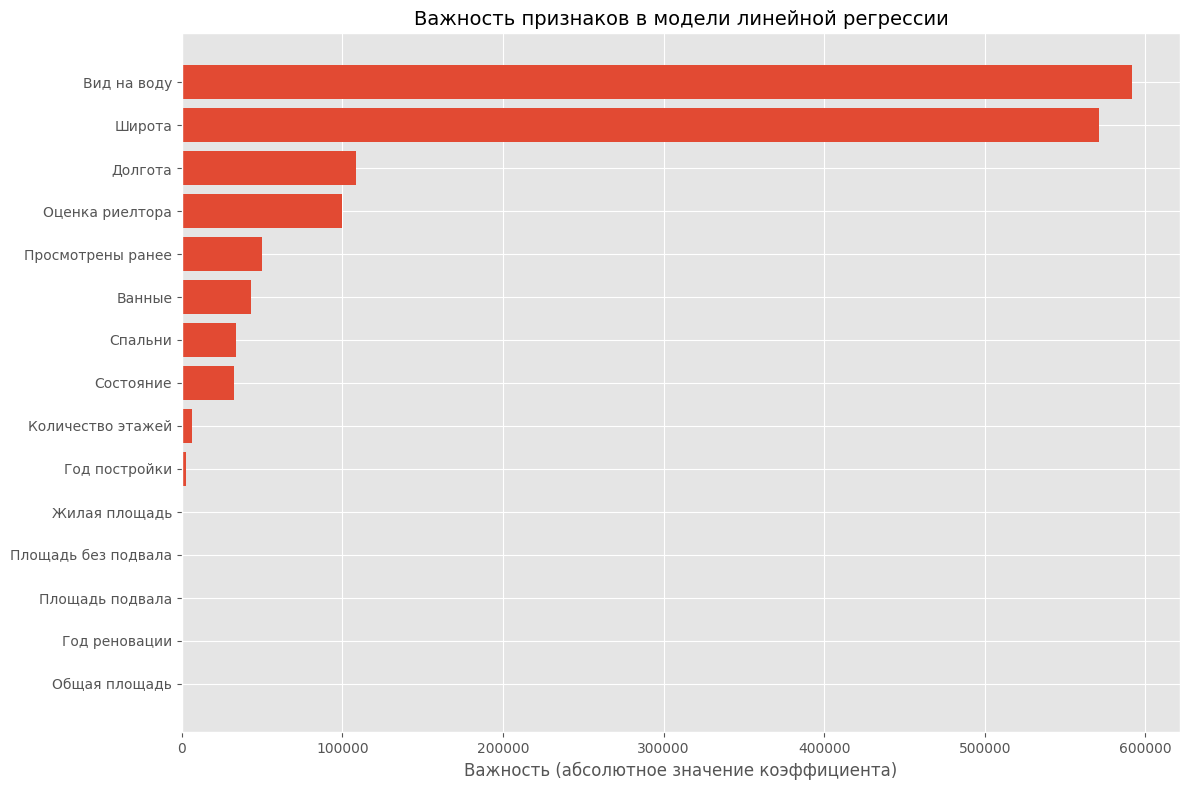

In [24]:
# Создаём переменные
training_points = train_data.drop('Целевая.Цена', axis=1)
training_values = train_data['Целевая.Цена']
test_points = test_data.drop('Целевая.Цена', axis=1)
test_values = test_data['Целевая.Цена']

# Обучаем простую линейную регрессию
from sklearn.linear_model import LinearRegression
simple_lr = LinearRegression()
simple_lr.fit(training_points, training_values)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_names = training_points.columns
coefficients = simple_lr.coef_

feature_importance = pd.DataFrame({
    'Название признака': feature_names,
    'Важность признака': np.abs(coefficients)
}).sort_values('Важность признака', ascending=False)

print("="*60)
print("ЗАДАНИЕ 3.7 - Важность признаков")
print("="*60)
print("\nТаблица важности признаков (отсортирована по убыванию):")
print(feature_importance.to_string(index=False))

# Сохраняем результат
feature_importance_table = feature_importance

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Название признака'], feature_importance['Важность признака'])
plt.xlabel('Важность (абсолютное значение коэффициента)', fontsize=12)
plt.title('Важность признаков в модели линейной регрессии', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [28]:
# Наиболее важные признаки: Вид на воду, Широта, Долгота.
# Наименее важные: Общая площадь, Год реновации.

## Задание 3.8


ЗАДАНИЕ 3.8 - Поиск аномально низких цен
Всего объектов в тестовой выборке: 6484
Объектов с заниженной ценой (реальная < предсказанной): 3385
Аномально низких цен (ошибка < -2*std): 64
Порог аномалии: 403762.70

Топ-10 самых аномально низких цен:
      Реальная цена  Предсказанная цена       Разница
632          425000        1.675003e+06 -1.250003e+06
4675         380000        1.459378e+06 -1.079378e+06
1032        2280000        3.282973e+06 -1.002973e+06
4270         995000        1.949650e+06 -9.546501e+05
3502         400000        1.328605e+06 -9.286053e+05
2765         357000        1.278702e+06 -9.217022e+05
2426         600000        1.391778e+06 -7.917783e+05
4838        1110000        1.844002e+06 -7.340025e+05
842          345600        1.046715e+06 -7.011154e+05
4643         650000        1.333893e+06 -6.838929e+05


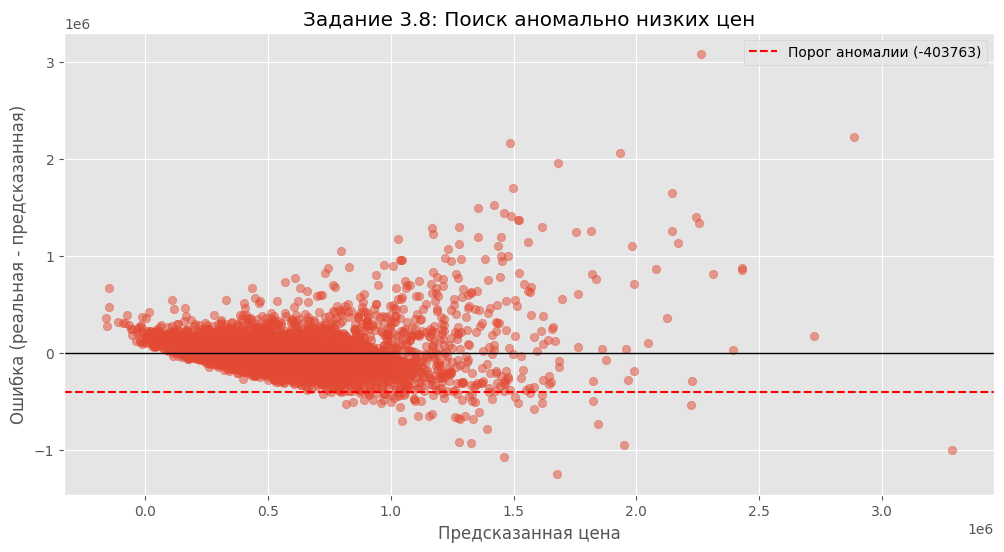

In [25]:
# Предсказания на тестовой выборке
y_pred = simple_lr.predict(test_points)
residuals = test_values - y_pred  # ошибки (реальная - предсказанная)

# Порог аномалии (2 стандартных отклонения)
threshold = 2 * residuals.std()
anomalies = residuals[residuals < -threshold]

print("\n" + "="*60)
print("ЗАДАНИЕ 3.8 - Поиск аномально низких цен")
print("="*60)
print(f"Всего объектов в тестовой выборке: {len(test_values)}")
print(f"Объектов с заниженной ценой (реальная < предсказанной): {len(residuals[residuals < 0])}")
print(f"Аномально низких цен (ошибка < -2*std): {len(anomalies)}")
print(f"Порог аномалии: {threshold:.2f}")

# Топ-10 самых аномальных
anomaly_df = pd.DataFrame({
    'Реальная цена': test_values[residuals < -threshold],
    'Предсказанная цена': y_pred[residuals < -threshold],
    'Разница': residuals[residuals < -threshold]
}).sort_values('Разница')

print("\nТоп-10 самых аномально низких цен:")
print(anomaly_df.head(10).to_string())

# Визуализация аномалий
plt.figure(figsize=(12, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.axhline(y=-threshold, color='red', linestyle='--', label=f'Порог аномалии (-{threshold:.0f})')
plt.xlabel('Предсказанная цена')
plt.ylabel('Ошибка (реальная - предсказанная)')
plt.title('Задание 3.8: Поиск аномально низких цен')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Найдено 64 аномально низких цены (ошибка < -2σ).
# Потенциально выгодные предложения для покупки.